# Instructions

1. To generate all figures, ensure the test-file is loaded from the tests directory in this repository.
2. Click Run All to generate all the tutorial figures and analyzed classes
3. Read through the header text to parse and understand each section in detail.

Author: Martin Jasinski, Cindy Shaheen (Oct. 2026)

Leslie Lab

GCRC-cluster-hckthn 1

In [24]:
from src.toolsjasinski._parse_video import parse_video
from src.toolsjasinski._split_ALEX import split_ALEX
import numpy as np
import matplotlib.pyplot as plt
import csv

# File Loading

In [25]:
path = r'src\toolsjasinski\tests\ALEX_Nanowells_10mWRL_50mWGL_3MM_2min.nd2'

video = parse_video(path)

print(video)
print(f"File Size: {video.nbytes/1e9:.2f} Gb")
print(video.sizes)
print('pixel-size', video['X'].values[1], video['X'].attrs['units'])

<xarray.DataArray '_dask_block-aacbdb2a18dff2e73fd9cf0b459a7cc1' (T: 2378,
                                                                  C: 2, Z: 1,
                                                                  Y: 512, X: 512)> Size: 2GB
dask.array<transpose, shape=(2378, 2, 1, 512, 512), dtype=uint16, chunksize=(1, 2, 1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * T        (T) float64 19kB 0.0 50.48 101.0 ... 1.199e+05 1.199e+05 1.2e+05
  * C        (C) <U5 40B 'red' 'green'
  * Z        (Z) float64 8B 0.0
  * Y        (Y) float64 4kB 0.0 0.16 0.32 0.48 0.64 ... 81.28 81.44 81.6 81.76
  * X        (X) float64 4kB 0.0 0.16 0.32 0.48 0.64 ... 81.28 81.44 81.6 81.76
Attributes:
    metadata:   {'metadata': Metadata(contents=Contents(channelCount=2, frame...
    processed:  images=[<1 field_type>] creator='N/A'
File Size: 2.49 Gb
Frozen({'T': 2378, 'C': 2, 'Z': 1, 'Y': 512, 'X': 512})
pixel-size 0.16 µm


# ALEX Splitting and xr. Dataset

In [26]:
alex_ds = split_ALEX(video)

# Tracking

Frame 792: 2657 trajectories present.


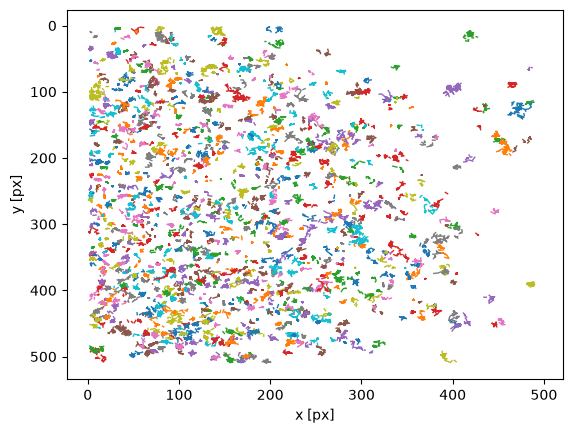

<Axes: xlabel='x [px]', ylabel='y [px]'>

In [21]:
import trackpy as tp
#tracking
trackDD = tp.batch(alex_ds["donorCam_donor"].values, diameter=5)
trackAD = tp.batch(alex_ds["acceptorCam_donor"].values, diameter=5)
# linking
t = tp.link(trackDD, 5, memory = 3)
f = tp.link(trackAD, 5, memory = 3)
# filter
t1 = tp.filter_stubs(t, 100)
f1 = tp.filter_stubs(f, 100)
# plotting
t1.head()
tp.plot_traj(t1)

In [22]:
t1.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,19.664026,138.094584,2015.230030,1.069000,0.208868,446.234359,28866.0,0.083014,0,105
0,26.352899,27.796952,586.883806,1.299750,0.205537,96.266607,20785.0,0.405486,0,138
0,26.780408,214.177419,2120.922330,1.047223,0.273001,475.162460,29087.0,0.081247,0,144
0,27.750334,71.122145,1121.374349,1.074761,0.224041,225.876954,23754.0,0.167059,0,152
0,31.409165,61.119044,1787.569837,1.123620,0.105266,357.129014,26252.0,0.111766,0,170


# Saving as an Output

In [ ]:
class ParticleClass():
    def __init__(self, video_filename, xy_red, xy_green, intensity_red, intensity_green) -> None:
        self.video_filename     = video_filename
        self.xy_red          = xy_red
        self.xy_green        = xy_green
        self.intensity_red   = intensity_red
        self.intensity_green = intensity_green

class Output():
    def __init__(self) -> None:
        self.date = None
        self.particle_array = []
    
    def add_particle(self, particle) -> None:
        assert isinstance(particle, ParticleClass)
        self.particle_array.append(particle)

    def serialize_to_csv(self, filepath: str) -> None:
        headers = ['date', 'video_index', 'particle_index', 'xy_red', 'xy_green', 'intensity_red', 'intensity_green']

        with open(filepath, mode='w', newline='', encoding = 'utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(headers)

            for particle in self.particle_array:
                writer.writerow([
                    self.date,
                    particle.video_index,
                    particle.particle_index,
                    particle.xy_red,
                    particle.xy_green,
                    particle.intensity_red,
                    particle.intensity_green
                ])

In [ ]:
out = Output()

# Loop using iterrows
for index, row in t1.iterrows():
    particle = ParticleClass(1, index, (row['x'], row['y']), (None), row['mass'], None)
    out.add_particle(particle)

In [ ]:
import csv
out.serialize_to_csv('test_csv.csv')